In [1]:
import librosa
import numpy as np

# 1. Load the audio file (convert to mono, keep original sample rate)
y, sr = librosa.load("5afc6a14-a9d8-45f8-b31d-c79dd87cc8c6-1430757039803-1.7-m-48-bu.wav", sr=None, mono=True)

# 2. Extract MFCCs (20 coefficients is common)
mfccs = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20,
    n_fft=2048,
    hop_length=512
)

# 3. Take mean over time (frames) → fixed-length feature vector

mfcc_scaled = np.mean(mfccs, axis=1)

print("MFCC shape (coefficients x frames):", mfccs.shape)

print("Final feature vector shape:", mfcc_scaled.shape)
print("MFCC feature vector:", mfcc_scaled)


MFCC shape (coefficients x frames): (20, 105)
Final feature vector shape: (20,)
MFCC feature vector: [-78.347534   -62.096066   -29.125002   -16.699863    -8.410232
  11.049842   -29.98773      4.1277885   -5.343027    -3.18253
  -6.297068    -0.08937752  -5.571544    -9.230918    -7.478739
  -0.70826995  -2.3293624   -4.562879    -5.886533     1.0416394 ]


In [2]:
# 4. Delta (1st derivative)
delta_mfcc = librosa.feature.delta(mfccs)

# 5. Delta-Delta (2nd derivative)
delta2_mfcc = librosa.feature.delta(mfccs, order=2)

# 6. Mean pooling
mfcc_mean = np.mean(mfccs, axis=1)
delta_mean = np.mean(delta_mfcc, axis=1)
delta2_mean = np.mean(delta2_mfcc, axis=1)

# 7. Combine all features
final_feature_vector = np.hstack([
    mfcc_mean,
    delta_mean,
    delta2_mean
])

print("Final feature vector shape:", final_feature_vector.shape)


Final feature vector shape: (60,)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
final_feature_vector = scaler.fit_transform(
    final_feature_vector.reshape(1, -1)
).flatten()


In [5]:
import os
import librosa
import numpy as np

DATASET_PATH = "data/raw"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]


In [6]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None, mono=True)

    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=20,
        n_fft=2048,
        hop_length=512
    )

    delta = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)

    feature_vector = np.hstack([
        np.mean(mfccs, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1)
    ])

    return feature_vector


In [7]:
X = []
y = []

for label, class_name in enumerate(CLASSES):
    class_folder = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_folder):
        if file.endswith(".wav"):
            filepath = os.path.join(class_folder, file)

            features = extract_features(filepath)

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (num_samples, 60)
print("y shape:", y.shape)  # (num_samples,)


X shape: (457, 60)
y shape: (457,)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test, y_pred, target_names=CLASSES, output_dict=True
)

df_report = pd.DataFrame(report)
print(df_report)


           belly_pain  burping  discomfort     hungry  tired  accuracy  \
precision         0.0      0.0         0.0   0.836957    0.0  0.836957   
recall            0.0      0.0         0.0   1.000000    0.0  0.836957   
f1-score          0.0      0.0         0.0   0.911243    0.0  0.836957   
support           3.0      2.0         5.0  77.000000    5.0  0.836957   

           macro avg  weighted avg  
precision   0.167391      0.700496  
recall      0.200000      0.836957  
f1-score    0.182249      0.762670  
support    92.000000     92.000000  


c:\Users\LOG IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LOG IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LOG IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95,random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_pca.shape[1])


Original features: 60
Reduced features: 47


In [ ]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_pca, y_train)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_final, y_train_final)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_pca)

print(classification_report(y_test, y_pred, target_names=CLASSES))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00         3
     burping       0.00      0.00      0.00         2
  discomfort       0.00      0.00      0.00         5
      hungry       0.83      0.97      0.90        77
       tired       0.00      0.00      0.00         5

    accuracy                           0.82        92
   macro avg       0.17      0.19      0.18        92
weighted avg       0.70      0.82      0.75        92

[[ 0  0  0  3  0]
 [ 0  0  0  2  0]
 [ 0  0  0  5  0]
 [ 0  0  1 75  1]
 [ 0  0  0  5  0]]


c:\Users\LOG IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LOG IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LOG IN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

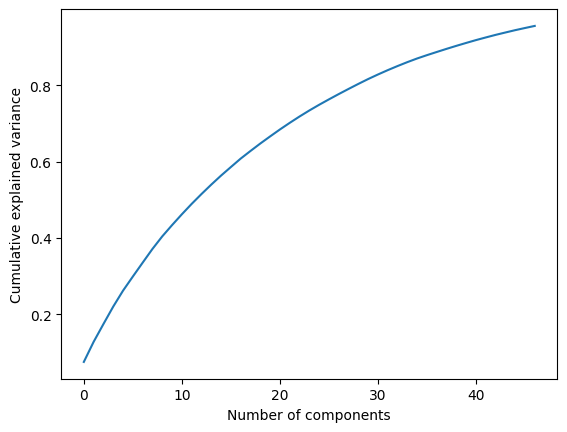

In [ ]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()


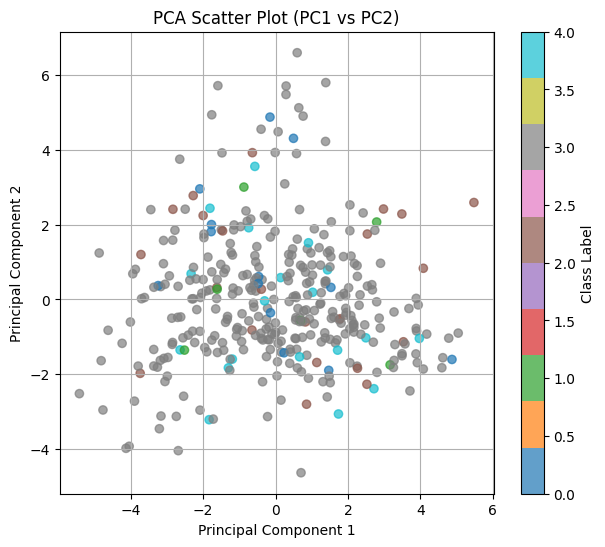

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# If you already have PCA features
# X_train_pca shape → (samples, components)

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_train_pca[:, 0],   # PC1
    X_train_pca[:, 1],   # PC2
    c=y_train,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (PC1 vs PC2)")

plt.colorbar(scatter, label="Class Label")
plt.grid(True)
plt.show()


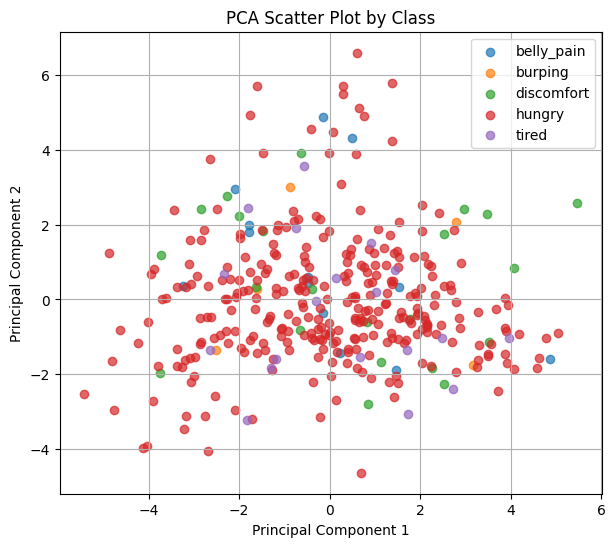

In [81]:
plt.figure(figsize=(7, 6))

for label, class_name in enumerate(CLASSES):
    idx = np.where(y_train == label)
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot by Class")
plt.legend()
plt.grid(True)
plt.show()
